<a href="https://colab.research.google.com/github/paul-66666/CS497-Capstone/blob/main/Root_cause_analysis_system_for_negative_reviews_WK7_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Path: /kaggle/input/amazon-reviews-us-beauty-v1-00-tsv-zip
TSV: /kaggle/input/amazon-reviews-us-beauty-v1-00-tsv-zip/amazon_reviews_us_Beauty_v1_00.tsv
Total rows after basic cleaning: 5115218


,product_title,star_rating,helpful_votes,total_votes,verified_purchase,review_body,review_date
0,The Naked Bee Vitmin C Moisturizing Sunscreen ...,5,0,0,Y,"Love this, excellent sun block!!",2015-08-31
1,"Alba Botanica Sunless Tanning Lotion, 4 Ounce",5,0,0,Y,The great thing about this cream is that it do...,2015-08-31
2,"Elysee Infusion Skin Therapy Elixir, 2oz.",5,0,0,Y,"Great Product, I'm 65 years old and this is al...",2015-08-31


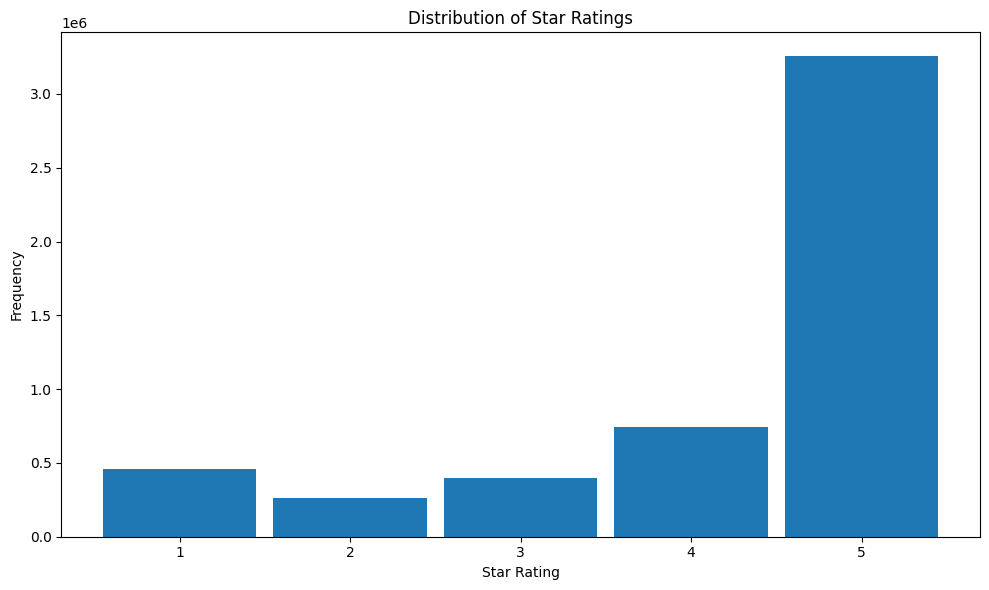

Sample size: 30000
label_negative
1    15000
0    15000
Name: count, dtype: int64


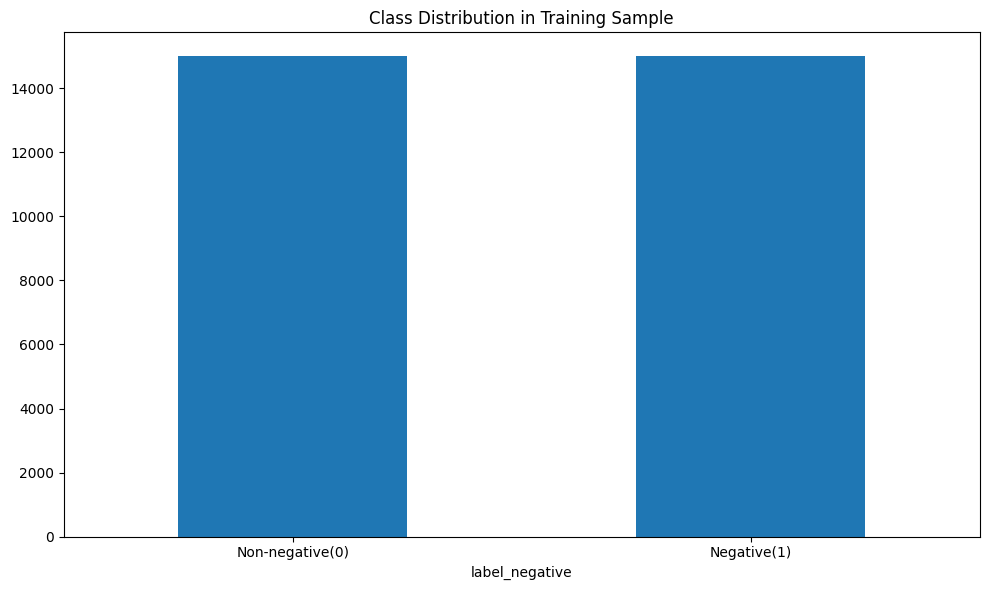

X_tr shape: (24000, 120) X_va shape: (6000, 120)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 120, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 120, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention_2              │ (None, 128)            │           248 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,385 (10.18 MB)

 Trainable params: 2,667,385 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 843ms/step - auc: 0.6243 - loss: 0.6471 - precision: 0.5825 - recall: 0.6642 - val_auc: 0.9087 - val_loss: 0.3936 - val_precision: 0.8189 - val_recall: 0.8503
Epoch 2/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 78s 830ms/step - auc: 0.9192 - loss: 0.3592 - precision: 0.8465 - recall: 0.8636 - val_auc: 0.9270 - val_loss: 0.3477 - val_precision: 0.8636 - val_recall: 0.8297
Epoch 3/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 829ms/step - auc: 0.9448 - loss: 0.2932 - precision: 0.8873 - recall: 0.8838 - val_auc: 0.9264 - val_loss: 0.3525 - val_precision: 0.8400 - val_recall: 0.8713
Epoch 4/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 876ms/step - auc: 0.9637 - loss: 0.2363 - precision: 0.9055 - recall: 0.9202 - val_auc: 0.9321 - val_loss: 0.3580 - val_precision: 0.8542 - val_recall: 0.8787
Epoch 5/6
94/94 ━━━━━━━━━━━━━━━━━━━━ 141s 863ms/step - auc: 0.9764 - loss: 0.1863 - precision: 0.9239 - recall: 0.9441 - val_auc: 0.9281 - val_loss: 0.3866 - val_precision: 0.8452 - val_recall: 0.8920

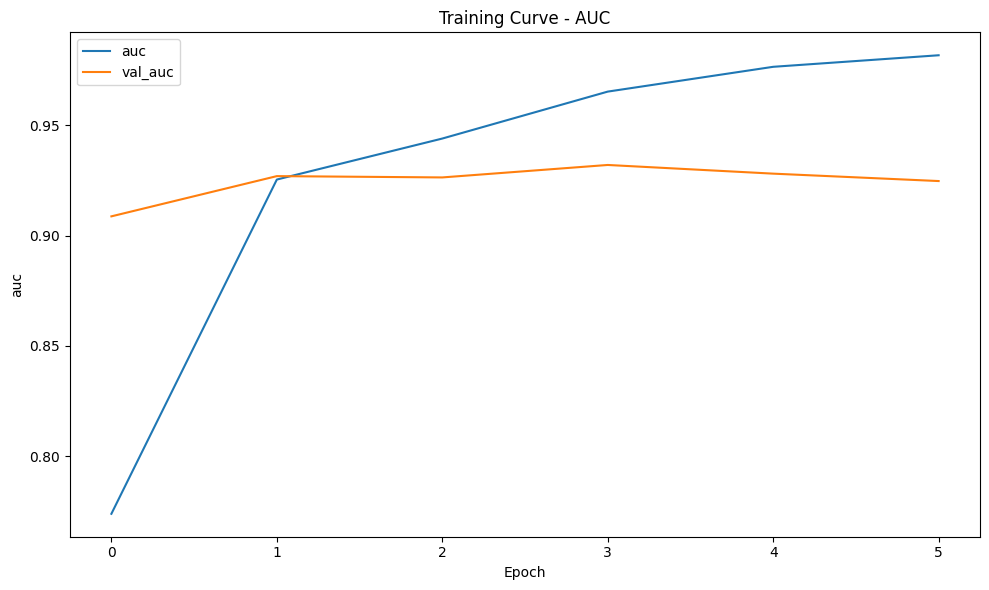

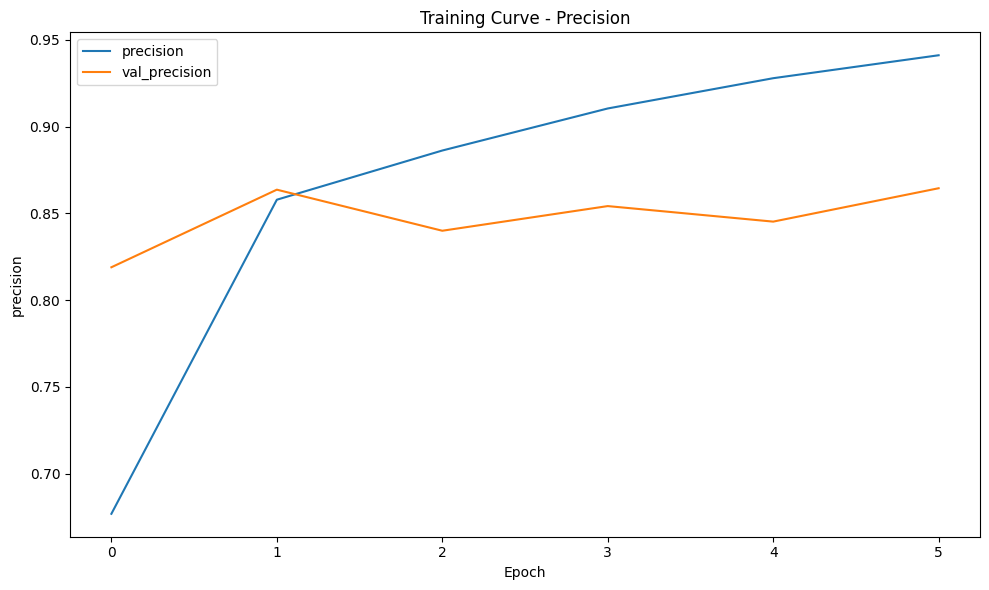

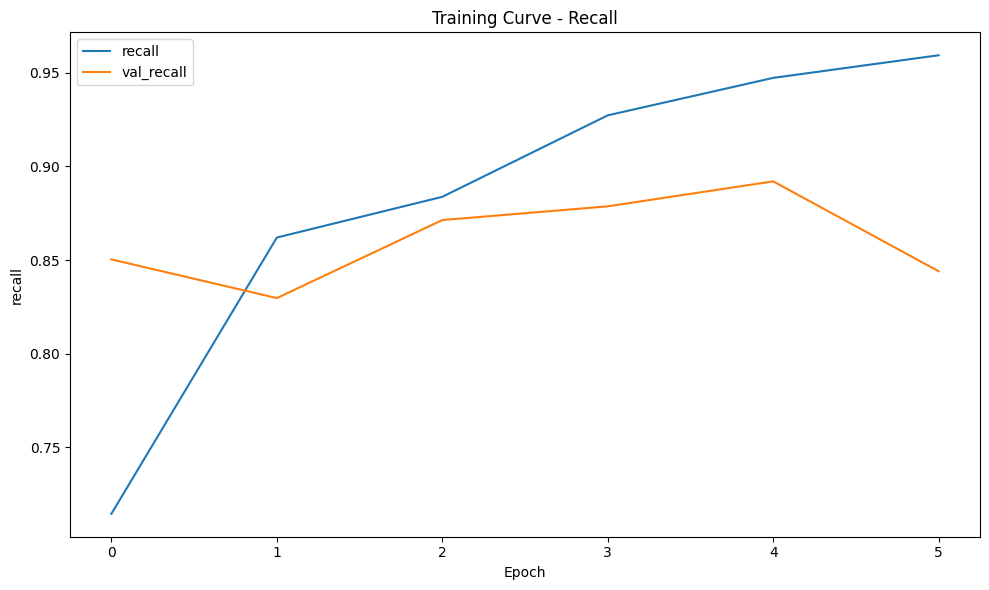

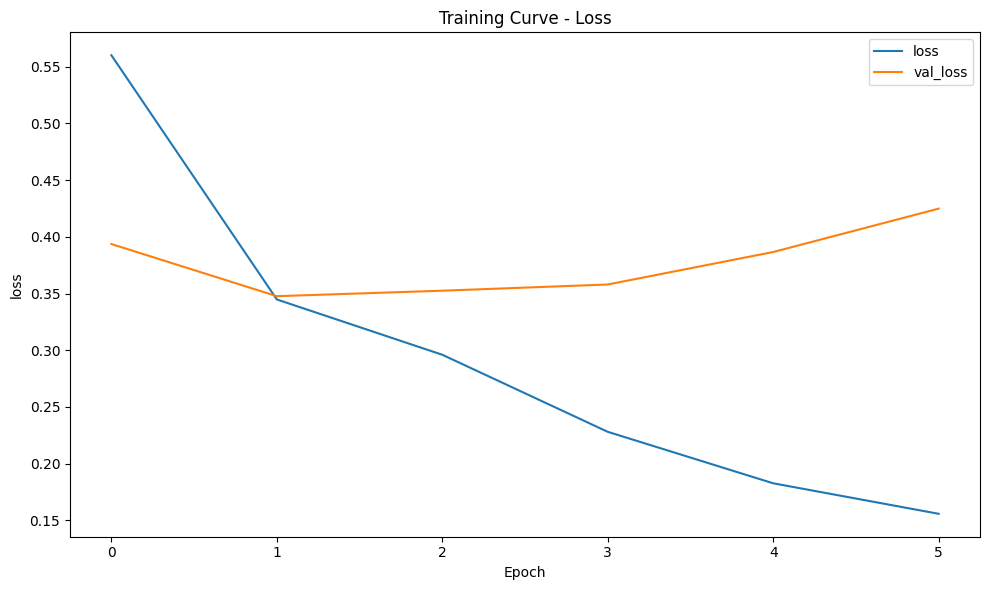

188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step
              precision    recall  f1-score   support

           0     0.8751    0.8500    0.8624      3000
           1     0.8542    0.8787    0.8663      3000

    accuracy                         0.8643      6000
   macro avg     0.8646    0.8643    0.8643      6000
weighted avg     0.8646    0.8643    0.8643      6000



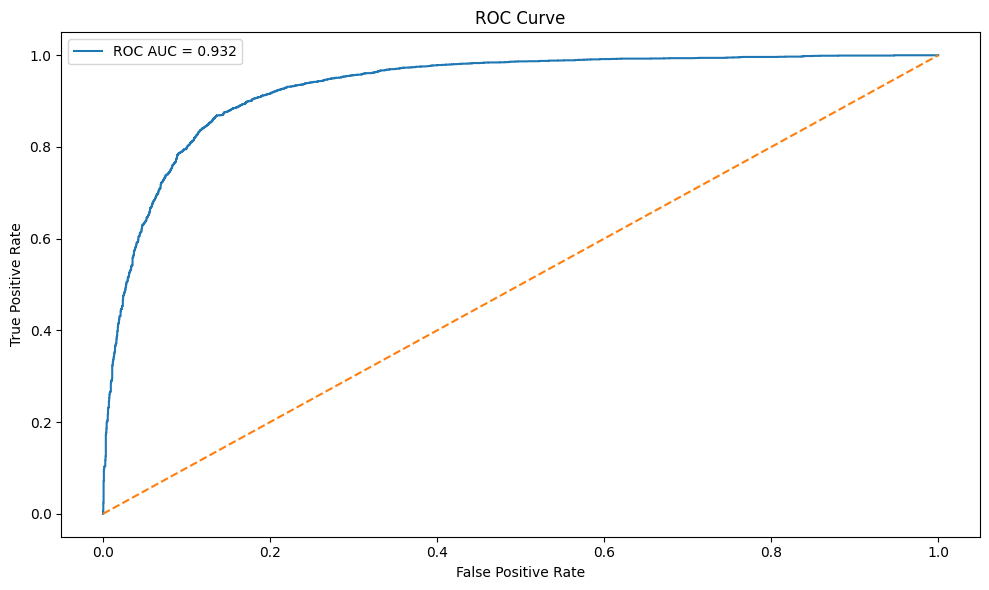

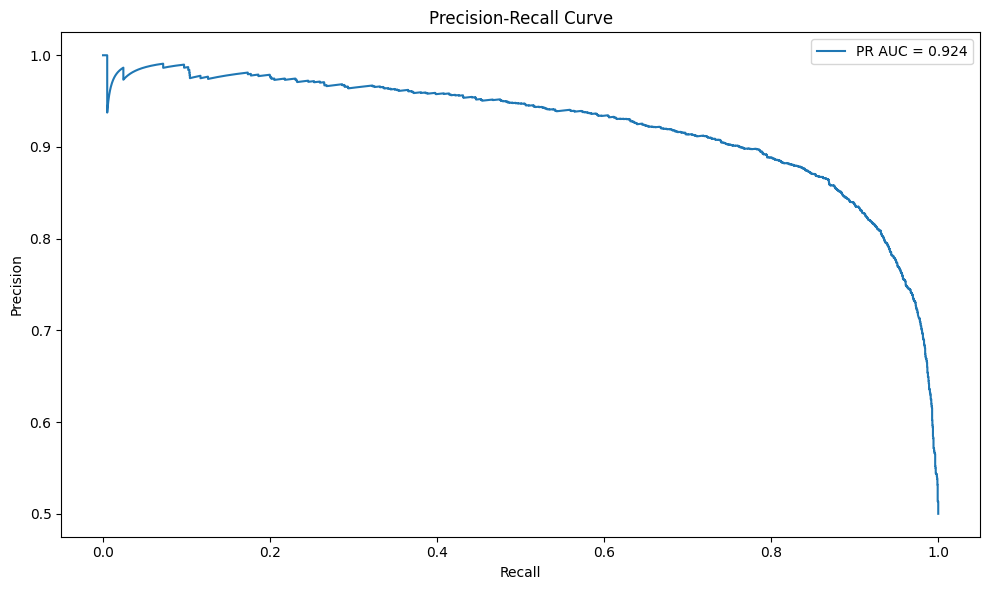

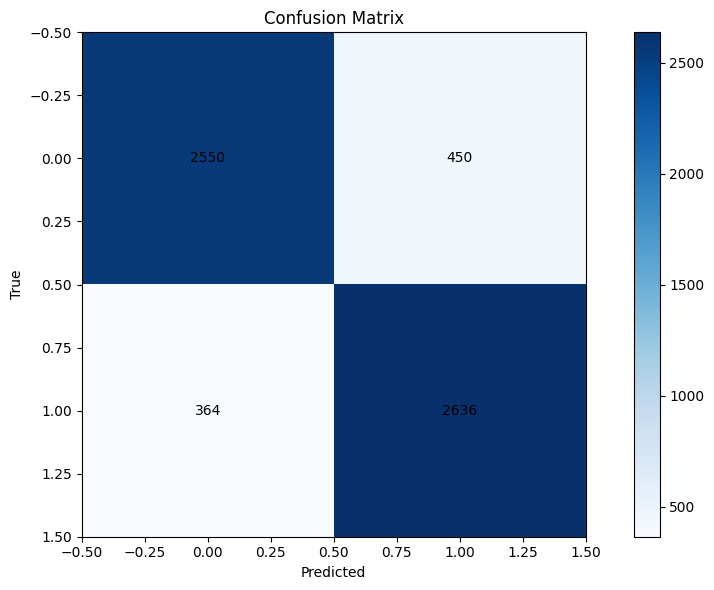

In [3]:
# ============================================================
#   Amazon Beauty Reviews → 评论级二分类（BiLSTM + 简易Attention）
#   Week 07
#   输出：若干有用图表（评分分布、类别分布、训练曲线、ROC、PR、混淆矩阵）
# ============================================================

# ---------------------------
# 【0】依赖安装（Colab）
# ---------------------------
# 只安装必须的：kagglehub 用于下载数据
!pip -q install kagglehub

# ---------------------------
# 【1】导入库
# ---------------------------
import os, re, zipfile, random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Layer
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------
# 【2】全局随机种子 & 画图设置
# ---------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
plt.rcParams["figure.figsize"] = (10, 6)   # 使用默认色，不设主题

# ---------------------------
# 【3】下载与定位数据
# ---------------------------
import kagglehub
path = kagglehub.dataset_download("beaglelee/amazon-reviews-us-beauty-v1-00-tsv-zip")
print("Path:", path)

# 解压&定位TSV
tsv_file, zip_file = None, None
for fname in os.listdir(path):
    if fname.lower().endswith(".tsv"):
        tsv_file = os.path.join(path, fname)
    if fname.lower().endswith(".zip"):
        zip_file = os.path.join(path, fname)

if tsv_file is None and zip_file is not None:
    with zipfile.ZipFile(zip_file, 'r') as zf:
        members = [m for m in zf.namelist() if m.lower().endswith(".tsv")]
        assert len(members) >= 1, "No TSV file found inside ZIP."
        zf.extract(members[0], path)
        tsv_file = os.path.join(path, members[0])

assert os.path.exists(tsv_file), "TSV not found."
print("TSV:", tsv_file)

# ---------------------------
# 【4】读取与基础清洗
# ---------------------------
usecols = ["star_rating", "review_body", "review_date",
           "product_title", "verified_purchase", "total_votes", "helpful_votes"]

df = pd.read_csv(tsv_file, sep='\t', usecols=usecols,
                 quoting=3, on_bad_lines='skip', dtype=str)

# 类型转换与最小清洗
df["star_rating"]  = pd.to_numeric(df["star_rating"],  errors="coerce")
df["total_votes"]  = pd.to_numeric(df["total_votes"],  errors="coerce")
df["helpful_votes"] = pd.to_numeric(df["helpful_votes"], errors="coerce")
df["review_body"]  = df["review_body"].fillna("").astype(str)

# 仅保留有星级且有文本
df = df.dropna(subset=["star_rating"])
df = df[df["review_body"].str.strip().str.len() > 0].reset_index(drop=True)

print("Total rows after basic cleaning:", len(df))
display(df.head(3))

# ---------------------------
# 【4.1】快速 EDA（有用图表 1/2）
# ---------------------------
# 评分分布
plt.figure()
df["star_rating"].plot(kind="hist", bins=[0.5,1.5,2.5,3.5,4.5,5.5], rwidth=0.9)
plt.xticks([1,2,3,4,5]); plt.xlabel("Star Rating"); plt.title("Distribution of Star Ratings")
plt.tight_layout(); plt.show()

# ---------------------------
# 【5】配置区（可按需调整）
# ---------------------------
# 抽样规模：为了在 Colab 快速跑通，可从3万起步；更稳可 8万~15万
MAX_SAMPLES = 30000

# 词表与序列长度
MAX_VOCAB = 20000
MAX_LEN   = 120

# BiLSTM 结构
EMB_DIM    = 128
LSTM_UNITS = 64
DROPOUT    = 0.30
EPOCHS     = 6
BATCH_SIZE = 256

# ---------------------------
# 【6】文本清洗 & 标签构造 & 抽样
# ---------------------------
CLEAN_RE = re.compile(r"http\S+|www\.\S+|<.*?>|[^a-zA-Z']+")

def clean_text(s: str) -> str:
    """基础清洗：小写、去URL/HTML/非字母、合并多空格"""
    s = s.lower()
    s = CLEAN_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# 标签：评论级负面/其他（训练二分类器）
df["label_negative"] = (df["star_rating"] <= 2).astype(int)

# 分层抽样（负类=1、非负=0 各采样一半），数据量较小时不抽样
neg_df = df[df["label_negative"] == 1]
pos_df = df[df["label_negative"] == 0]

if len(df) > MAX_SAMPLES and len(neg_df) > 0 and len(pos_df) > 0:
    n_each = min(MAX_SAMPLES // 2, len(neg_df), len(pos_df))
    df_small = pd.concat([
        neg_df.sample(n=n_each, random_state=SEED),
        pos_df.sample(n=n_each, random_state=SEED)
    ], ignore_index=True)
else:
    df_small = df.copy()

print("Sample size:", len(df_small))
print(df_small["label_negative"].value_counts())

# 类别分布条形图（有用图表 2/2）
plt.figure()
df_small["label_negative"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Non-negative(0)", "Negative(1)"], rotation=0)
plt.title("Class Distribution in Training Sample")
plt.tight_layout(); plt.show()

# ---------------------------
# 【7】训练/验证集切分 & 序列化
# ---------------------------
texts  = df_small["review_body"].astype(str).apply(clean_text).tolist()
labels = df_small["label_negative"].astype(int).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED, stratify=labels
)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

def to_seq(text_list):
    seq = tokenizer.texts_to_sequences(text_list)
    return pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_tr = to_seq(X_train_text)
X_va = to_seq(X_val_text)

print("X_tr shape:", X_tr.shape, "X_va shape:", X_va.shape)

# ---------------------------
# 【8】构建 BiLSTM + 简易 Attention
# ---------------------------
class SimpleAttention(Layer):
    """简易可解释 Attention：从 BiLSTM 隐状态中提取加权上下文"""
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight",
                                 shape=(input_shape[-1], 1),
                                 initializer="glorot_uniform",
                                 trainable=True)
        self.b = self.add_weight(name="att_bias",
                                 shape=(input_shape[1], 1),
                                 initializer="zeros",
                                 trainable=True)
        super().build(input_shape)

    def call(self, x):
        # x: [B, T, F]
        e = tf.keras.backend.squeeze(
            tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b), axis=-1)  # [B, T]
        a = tf.keras.backend.softmax(e)                  # 注意力权重 [B, T]
        a = tf.keras.backend.expand_dims(a)             # [B, T, 1]
        context = x * a                                  # 加权
        return tf.keras.backend.sum(context, axis=1)    # [B, F]

inputs = layers.Input(shape=(MAX_LEN,))
x = Embedding(input_dim=MAX_VOCAB, output_dim=EMB_DIM)(inputs)   # Keras 3 不再建议传 input_length
x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True))(x)
x = SimpleAttention()(x)
x = Dropout(DROPOUT)(x)
x = Dense(64, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)
model.summary()

# ---------------------------
# 【9】训练 & 训练曲线（有用图表）
# ---------------------------
early = EarlyStopping(monitor="val_auc", patience=3, mode="max", restore_best_weights=True)

history = model.fit(
    X_tr, y_train,
    validation_data=(X_va, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early], verbose=1
)

# 训练曲线：AUC / Precision / Recall / Loss
def plot_metric(h, key, title=None):
    if key in h.history and ("val_" + key) in h.history:
        plt.figure()
        plt.plot(h.history[key], label=key)
        plt.plot(h.history["val_" + key], label="val_" + key)
        plt.xlabel("Epoch"); plt.ylabel(key); plt.title(title or key)
        plt.legend(); plt.tight_layout(); plt.show()

plot_metric(history, "auc", "Training Curve - AUC")
plot_metric(history, "precision", "Training Curve - Precision")
plot_metric(history, "recall", "Training Curve - Recall")
plot_metric(history, "loss", "Training Curve - Loss")

# ---------------------------
# 【10】评估：报告、ROC、PR、混淆矩阵（有用图表）
# ---------------------------
y_score = model.predict(X_va).ravel()
y_pred  = (y_score >= 0.5).astype(int)

print(classification_report(y_val, y_pred, digits=4))

# ROC
fpr, tpr, _ = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(); plt.tight_layout(); plt.show()

# PR
prec, rec, _ = precision_recall_curve(y_val, y_score)
pr_auc = auc(rec, prec)
plt.figure()
plt.plot(rec, prec, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve")
plt.legend(); plt.tight_layout(); plt.show()

# 混淆矩阵（数值标注）
cm = confusion_matrix(y_val, y_pred)
plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix"); plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()
